In [1]:
import os, json, time, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torchvision import models, transforms
from sentence_transformers import SentenceTransformer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (precision_recall_curve, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

DATA_DIR = "../dataset"
IMG_DIR = f"{DATA_DIR}/train_images"
RES_DIR = "results"
os.makedirs(RES_DIR, exist_ok=True)

N_IMAGES = 10000        # None = poora train set (GPU ho to). Pehle 10000 se chalao.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": False})
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
full = pd.read_csv(f"{DATA_DIR}/train.csv")
print("Full train:", full.shape)

if N_IMAGES:
    gs = full.groupby("label_group").size()
    order = rng.permutation(gs.index.values)
    cum = gs.loc[order].cumsum().values
    keep = order[: np.searchsorted(cum, N_IMAGES) + 1]
    df = full[full["label_group"].isin(keep)].reset_index(drop=True)
else:
    df = full.copy()

print("Working set:", df.shape, "| groups:", df["label_group"].nunique())
df.head()

Full train: (34250, 5)
Working set: (10001, 5) | groups: 3184


,posting_id,image,image_phash,title,label_group
0,train_86570404,0019a3c6755a194cb2e2c12bfc63972e.jpg,ea9af4f483249972,"[LOGU] Tempelan kulkas magnet angka, tempelan angka magnet",2359912463
1,train_4287573913,001f5580b058c6b8e33132190a757318.jpg,dc85e1750687f932,Charger VIZZ VZ-TC11 / batok charger vizz 1A ORIGINAL REAL KAPASITAS,1932232224
2,train_2238403912,003524b70715bf6bfa00451ca08e66e0.jpg,ba35c44a3fb7c068,Kangaroo Teflon / Allu Fry Pan 18 cm - KG652,531768918
3,train_1617041019,004811219262c545d74e427c5ea2d724.jpg,eae237c46618c799,Molina Kaftan / YADITA SPARKLE KAFTAN / KEANU DIAMOND KAFTAN / Talisha Kaftan,894203507
4,train_2410183091,004822e4ab7dd38455a134fb2f2dd05e.jpg,ba4ac2435eb989b6,B33F My Food Shop Shopping Trolley - ST. 003 troli mainan edukasi anak keran...,2464977091


Width  min/median/max: 225 / 700 / 4167
Height min/median/max: 225 / 700 / 4167
Non-square images: 0.2%


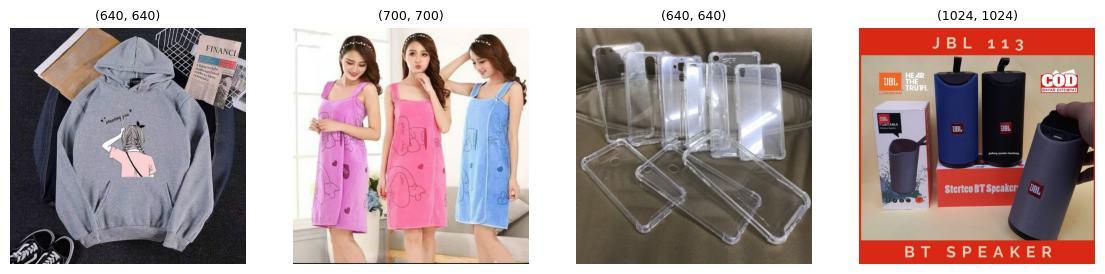

In [3]:
def load_img(fname):
    try:
        return Image.open(f"{IMG_DIR}/{fname}").convert("RGB")   # RGB: kuch images grayscale/RGBA hoti hain
    except Exception as e:
        print("Bad image:", fname, e)
        return Image.new("RGB", (224, 224))

samp = df.sample(1000, random_state=SEED)
sz = np.array([Image.open(f"{IMG_DIR}/{f}").size for f in samp["image"]])
print(f"Width  min/median/max: {sz[:,0].min()} / {int(np.median(sz[:,0]))} / {sz[:,0].max()}")
print(f"Height min/median/max: {sz[:,1].min()} / {int(np.median(sz[:,1]))} / {sz[:,1].max()}")
print(f"Non-square images: {(sz[:,0] != sz[:,1]).mean():.1%}")

fig, ax = plt.subplots(1, 4, figsize=(14, 3.5))
for a, (_, r) in zip(ax, samp.head(4).iterrows()):
    a.imshow(load_img(r["image"])); a.set_title(f"{Image.open(f'{IMG_DIR}/{r.image}').size}", fontsize=9); a.axis("off")
plt.show()

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
va_idx, te_idx = next(gss.split(df, groups=df["label_group"]))

print("val :", len(va_idx), "listings |", df.loc[va_idx, "label_group"].nunique(), "groups")
print("test:", len(te_idx), "listings |", df.loc[te_idx, "label_group"].nunique(), "groups")
print("Group overlap:", len(set(df.loc[va_idx, "label_group"]) & set(df.loc[te_idx, "label_group"])))  # 0

val : 4880 listings | 1592 groups
test: 5121 listings | 1592 groups
Group overlap: 0


In [5]:
TPATH = f"{RES_DIR}/timings.json"
TIMES = json.load(open(TPATH)) if os.path.exists(TPATH) else {}
files = df["image"].tolist()
BS = 64

def cached(name, fn):
    path = f"{RES_DIR}/emb_{name}_{len(df)}.npy"
    if os.path.exists(path):
        return np.load(path)
    t0 = time.time()
    E = fn()
    TIMES[f"{name}_{len(df)}"] = round(time.time() - t0, 1)
    json.dump(TIMES, open(TPATH, "w"))
    np.save(path, E)
    return E

# ---------------- ResNet50 (baseline) ----------------
rn_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),   # ImageNet stats
])

def run_resnet():
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = torch.nn.Identity()               # classification head hatao, 2048-d pooled feature milega
    m.to(DEVICE).eval()
    out = []
    with torch.no_grad():
        for s in tqdm(range(0, len(files), BS), desc="ResNet50"):
            x = torch.stack([rn_tfm(load_img(f)) for f in files[s:s + BS]]).to(DEVICE)
            out.append(m(x).cpu().numpy())
    return np.concatenate(out)

# ---------------- CLIP ViT-B/32 ----------------
def run_clip():
    m = SentenceTransformer("clip-ViT-B-32", device=DEVICE)
    out = []
    for s in tqdm(range(0, len(files), BS), desc="CLIP"):
        ims = [load_img(f) for f in files[s:s + BS]]
        out.append(m.encode(ims, batch_size=BS, convert_to_numpy=True, normalize_embeddings=False, show_progress_bar=False))
    return np.concatenate(out)

E_rn_raw = cached("resnet50", run_resnet)
E_clip_raw = cached("clip_vitb32", run_clip)

def l2n(E):
    return E / np.linalg.norm(E, axis=1, keepdims=True).clip(1e-12)

E_rn, E_clip = l2n(E_rn_raw), l2n(E_clip_raw)
print("ResNet50:", E_rn_raw.shape, "| CLIP:", E_clip_raw.shape)
print("Extraction time (s):", TIMES)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\shrey/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:08<00:00, 11.4MB/s]
CLIP: 100%|██████████| 157/157 [11:41<00:00,  4.47s/it]


ResNet50: (10001, 2048) | CLIP: (10001, 512)
Extraction time (s): {'resnet50_10001': 1170.4, 'clip_vitb32_10001': 757.0}


Image: 0019a3c6755a194cb2e2c12bfc63972e.jpg | group: 2359912463
Embedding shape : (512,)
First 8 values  : [ 0.089 -0.261  0.401  0.224 -0.585 -0.203  0.237  0.392]
L2 norm (raw)   : 10.866
L2 norm (normed): 1.0
ResNet50  cosine(same product pair) = 0.387 | cosine(different pair) = 0.123
CLIP      cosine(same product pair) = 0.765 | cosine(different pair) = 0.315


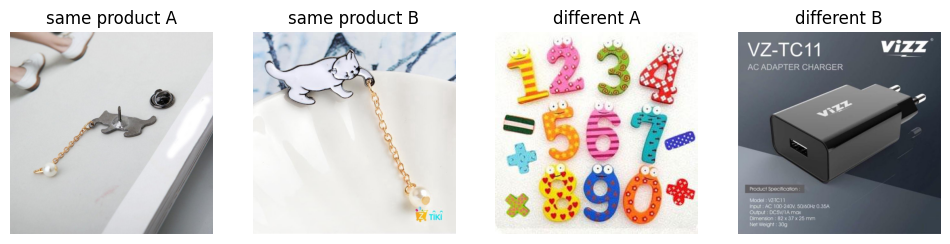

In [6]:
i = 0
print("Image:", df.loc[i, "image"], "| group:", df.loc[i, "label_group"])
print("Embedding shape :", E_clip_raw[i].shape)
print("First 8 values  :", np.round(E_clip_raw[i][:8], 3))
print("L2 norm (raw)   :", round(float(np.linalg.norm(E_clip_raw[i])), 3))
print("L2 norm (normed):", round(float(np.linalg.norm(E_clip[i])), 3))

grp = df.groupby("label_group").indices
same = next(v for v in grp.values() if len(v) >= 2)[:2]
diff = [0, int(np.where(df.label_group.values != df.label_group.values[0])[0][0])]

for name, E in [("ResNet50", E_rn), ("CLIP", E_clip)]:
    print(f"{name:9s} cosine(same product pair) = {E[same[0]] @ E[same[1]]:.3f} | cosine(different pair) = {E[diff[0]] @ E[diff[1]]:.3f}")

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for a, k in zip(ax, list(same) + diff):
    a.imshow(load_img(df.loc[k, "image"])); a.axis("off")
ax[0].set_title("same product A"); ax[1].set_title("same product B"); ax[2].set_title("different A"); ax[3].set_title("different B")
plt.show()

In [7]:
def make_pairs(pool, seed, max_pos=3):
    rng = np.random.default_rng(seed)
    pool = np.asarray(pool)
    labels = df["label_group"].values

    # positives: same group, ek group se max 3 pairs
    pos = []
    for lbl, members in df.loc[pool].groupby("label_group").groups.items():
        allp = list(itertools.combinations(list(members), 2))
        if len(allp) > max_pos:
            sel = rng.choice(len(allp), max_pos, replace=False)
            allp = [allp[i] for i in sel]
        pos += allp


    n_neg = len(pos); n_hard = n_neg // 2; n_rand = n_neg - n_hard

    # random negatives (easy)
    rand = set()
    while len(rand) < n_rand:
        a, b = rng.choice(pool, 2, replace=False)
        if labels[a] != labels[b]:
            rand.add((min(a, b), max(a, b)))

    # hard negatives: TITLE TF-IDF se mine (image model se nahi, taaki image models ke saath bias na ho)
    tf = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b", sublinear_tf=True)
    X = tf.fit_transform(df.loc[pool, "title"].str.lower())
    lp = labels[pool]
    hard, order = set(), rng.permutation(len(pool))
    for s in range(0, len(order), 500):
        if len(hard) >= n_hard:
            break
        a = order[s:s + 500]
        S = (X[a] @ X.T).toarray()
        S[lp[a][:, None] == lp[None, :]] = -1            # same group aur khud ko hatao
        top = np.argpartition(-S, 5, axis=1)[:, :5]
        pick = top[np.arange(len(a)), rng.integers(0, 5, len(a))]
        for ai, pi in zip(a, pick):
            x, y = pool[ai], pool[pi]
            hard.add((min(x, y), max(x, y)))
    hard = list(hard); rng.shuffle(hard); hard = hard[:n_hard]

    rows = ([(a, b, 1, "pos") for a, b in pos] +
            [(a, b, 0, "rand_neg") for a, b in rand] +
            [(a, b, 0, "hard_neg") for a, b in hard])
    P = pd.DataFrame(rows, columns=["a", "b", "y", "kind"]).sample(frac=1, random_state=seed).reset_index(drop=True)
    P["title_a"], P["title_b"] = df["title"].values[P.a], df["title"].values[P.b]
    P["img_a"], P["img_b"] = df["image"].values[P.a], df["image"].values[P.b]
    return P

P_val = make_pairs(va_idx, SEED)
P_test = make_pairs(te_idx, SEED + 1)
yv, yt = P_val["y"].values, P_test["y"].values
m_rand_t = (P_test["kind"] != "hard_neg").values
m_hard_t = (P_test["kind"] != "rand_neg").values

for n, P in [("val", P_val), ("test", P_test)]:
    print(n, len(P), P["kind"].value_counts().to_dict())

val 5460 {'pos': 2730, 'rand_neg': 1365, 'hard_neg': 1365}
test 5568 {'pos': 2784, 'hard_neg': 1392, 'rand_neg': 1392}


In [8]:
def best_threshold(y, s):
    p, r, t = precision_recall_curve(y, s)
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
    i = int(np.argmax(f1))
    return t[i], f1[i]

def evaluate(sv, st):
    thr, f1v = best_threshold(yv, sv)            # threshold sirf val par tune
    pred = st >= thr
    return dict(Threshold=round(float(thr), 4), Val_F1=round(f1v, 4),
                Test_P=round(precision_score(yt, pred), 4), Test_R=round(recall_score(yt, pred), 4),
                Test_F1=round(f1_score(yt, pred), 4), AUC=round(roc_auc_score(yt, st), 4),
                AP=round(average_precision_score(yt, st), 4),
                AP_randneg=round(average_precision_score(yt[m_rand_t], st[m_rand_t]), 4),
                AP_hardneg=round(average_precision_score(yt[m_hard_t], st[m_hard_t]), 4))

def pair_scores(E, P, how="cosine"):
    A, B = E[P.a.values], E[P.b.values]
    if how == "euclidean":
        return -np.linalg.norm(A - B, axis=1)          # negative distance: bada = zyada similar
    return (A * B).sum(1)                              # cosine (normalised E) ya raw dot product

RESULTS, SCORES = [], {}
def run_exp(exp, model, E, dim, how, label):
    sv, st = pair_scores(E, P_val, how), pair_scores(E, P_test, how)
    r = dict(Experiment=exp, Model=model, Dim=dim, Similarity=label, **evaluate(sv, st))
    RESULTS.append(r); SCORES[exp] = {"val": sv, "test": st}
    return pd.DataFrame([r])

run_exp("Baseline", "ResNet50 (ImageNet)", E_rn, E_rn.shape[1], "cosine", "Cosine")
run_exp("Exp1", "CLIP ViT-B/32", E_clip, E_clip.shape[1], "cosine", "Cosine")
res = pd.DataFrame(RESULTS)
res

,Experiment,Model,Dim,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,AUC,AP,AP_randneg,AP_hardneg
0,Baseline,ResNet50 (ImageNet),2048,Cosine,0.4543,0.8606,0.8344,0.8958,0.8640,0.9382,0.9438,0.9890,0.9507
1,Exp1,CLIP ViT-B/32,512,Cosine,0.6368,0.8486,0.8422,0.8495,0.8459,0.9255,0.9320,0.9864,0.9403


In [9]:
rows = []
for model, Eraw, En in [("ResNet50", E_rn_raw, E_rn), ("CLIP", E_clip_raw, E_clip)]:
    configs = [
        ("Cosine (normalised)",         En,   "cosine"),
        ("Euclidean (normalised)",      En,   "euclidean"),
        ("Dot product (raw, no norm)",  Eraw, "cosine"),      # raw par (A*B).sum = dot product
        ("Euclidean (raw, no norm)",    Eraw, "euclidean"),
    ]
    for label, E, how in configs:
        sv, st = pair_scores(E, P_val, how), pair_scores(E, P_test, how)
        rows.append(dict(Model=model, Similarity=label, **evaluate(sv, st)))
sim_df = pd.DataFrame(rows)[["Model", "Similarity", "AP", "AP_hardneg", "Val_F1", "Test_F1", "Threshold"]]
sim_df.to_csv(f"{RES_DIR}/similarity_measures.csv", index=False)
sim_df

,Model,Similarity,AP,AP_hardneg,Val_F1,Test_F1,Threshold
0,ResNet50,Cosine (normalised),0.9438,0.9507,0.8606,0.8640,0.4543
1,ResNet50,Euclidean (normalised),0.9438,0.9507,0.8606,0.8640,-1.0447
2,ResNet50,"Dot product (raw, no norm)",0.8975,0.9141,0.8337,0.8278,65.6598
3,ResNet50,"Euclidean (raw, no norm)",0.9096,0.9282,0.8059,0.8140,-12.9029
4,CLIP,Cosine (normalised),0.9320,0.9403,0.8486,0.8459,0.6368
5,CLIP,Euclidean (normalised),0.9320,0.9403,0.8486,0.8459,-0.8522
6,CLIP,"Dot product (raw, no norm)",0.8732,0.8967,0.7868,0.7948,53.5349
7,CLIP,"Euclidean (raw, no norm)",0.9407,0.9469,0.8563,0.8595,-8.2825


Final model: Baseline | ResNet50 (ImageNet)
Chosen threshold (val max-F1) = 0.454


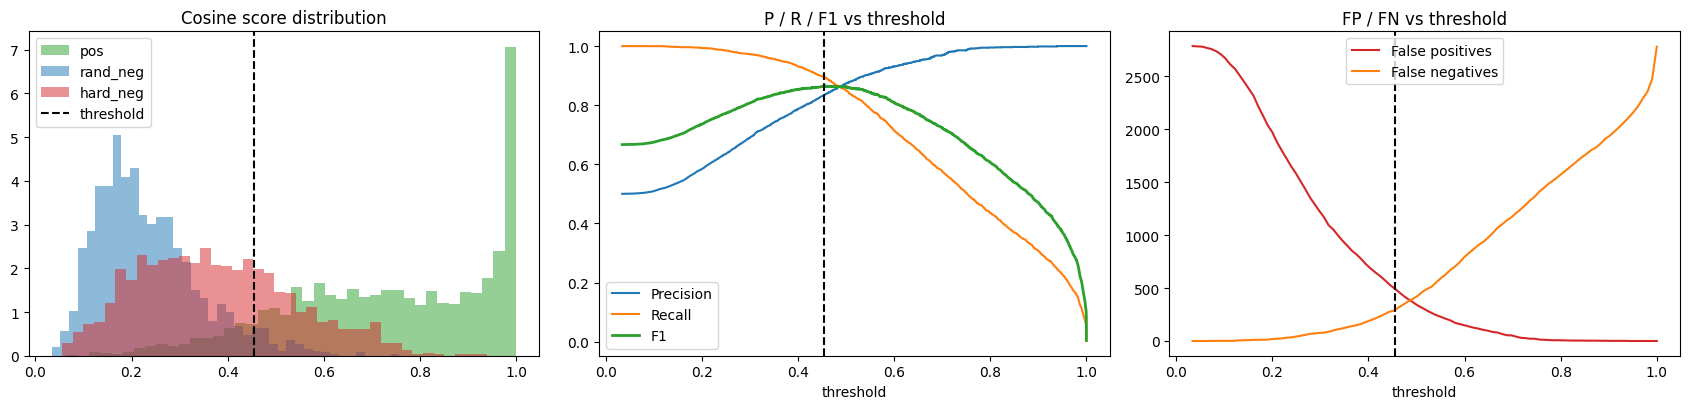

,threshold,precision,recall,f1,FP,FN
0,0.354,0.745,0.954,0.837,907,128
1,0.454,0.834,0.896,0.864,495,290
2,0.554,0.908,0.781,0.840,221,609


In [10]:
final = res.sort_values("Val_F1").iloc[-1]["Experiment"]      # val F1 se best model
print("Final model:", final, "|", res.set_index("Experiment").loc[final, "Model"])
sv_f, st_f = SCORES[final]["val"], SCORES[final]["test"]
thr_f, _ = best_threshold(yv, sv_f)
print(f"Chosen threshold (val max-F1) = {thr_f:.3f}")

p_t, r_t, t_t = precision_recall_curve(yt, st_f)
f1_t = 2 * p_t[:-1] * r_t[:-1] / (p_t[:-1] + r_t[:-1] + 1e-12)
grid = np.linspace(st_f.min(), st_f.max(), 100)
fp = np.array([((st_f >= t) & (yt == 0)).sum() for t in grid])
fn = np.array([((st_f < t) & (yt == 1)).sum() for t in grid])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
for kind, c in [("pos", "tab:green"), ("rand_neg", "tab:blue"), ("hard_neg", "tab:red")]:
    ax[0].hist(st_f[(P_test.kind == kind).values], bins=40, alpha=0.5, density=True, label=kind, color=c)
ax[0].axvline(thr_f, color="k", ls="--", label="threshold"); ax[0].set_title("Cosine score distribution"); ax[0].legend()
ax[1].plot(t_t, p_t[:-1], label="Precision"); ax[1].plot(t_t, r_t[:-1], label="Recall"); ax[1].plot(t_t, f1_t, label="F1", lw=2)
ax[1].axvline(thr_f, color="k", ls="--"); ax[1].set_title("P / R / F1 vs threshold"); ax[1].set_xlabel("threshold"); ax[1].legend()
ax[2].plot(grid, fp, label="False positives", color="tab:red"); ax[2].plot(grid, fn, label="False negatives", color="tab:orange")
ax[2].axvline(thr_f, color="k", ls="--"); ax[2].set_title("FP / FN vs threshold"); ax[2].set_xlabel("threshold"); ax[2].legend()
plt.tight_layout(); plt.savefig(f"{RES_DIR}/threshold_analysis.png", dpi=150); plt.show()

rows = []
for t in [thr_f - 0.1, thr_f, thr_f + 0.1]:
    pred = st_f >= t
    rows.append(dict(threshold=round(float(t), 3), precision=round(precision_score(yt, pred), 3),
                     recall=round(recall_score(yt, pred), 3), f1=round(f1_score(yt, pred), 3),
                     FP=int((pred & (yt == 0)).sum()), FN=int((~pred & (yt == 1)).sum())))
pd.DataFrame(rows)

In [11]:
def retrieval_eval(E, idx, K=10, chunk=1000):
    Et, lt = E[idx], df["label_group"].values[idx]
    cnt = pd.Series(lt).value_counts()
    gsz = pd.Series(lt).map(cnt).values
    p1, rec = [], []
    for s in range(0, len(Et), chunk):
        S = Et[s:s + chunk] @ Et.T
        S[np.arange(S.shape[0]), np.arange(s, s + S.shape[0])] = -np.inf     # khud ko hatao
        top = np.argpartition(-S, K, axis=1)[:, :K]
        vals = np.take_along_axis(S, top, 1)
        top = np.take_along_axis(top, np.argsort(-vals, axis=1), 1)
        hit = lt[top] == lt[s:s + chunk, None]
        p1.append(hit[:, 0])
        rec.append(hit.sum(1) / np.minimum(K, gsz[s:s + chunk] - 1))
    return np.concatenate(p1).mean(), np.concatenate(rec).mean()

rows = []
for name, E in [("ResNet50", E_rn), ("CLIP", E_clip)]:
    p1, rk = retrieval_eval(E, te_idx)
    rows.append(dict(Model=name, **{"P@1 (top-1 same product)": round(p1, 4), "Recall@10": round(rk, 4)}))
ret = pd.DataFrame(rows)
ret.to_csv(f"{RES_DIR}/retrieval_metrics.csv", index=False)
ret

,Model,P@1 (top-1 same product),Recall@10
0,ResNet50,0.7292,0.7324
1,CLIP,0.7418,0.7627


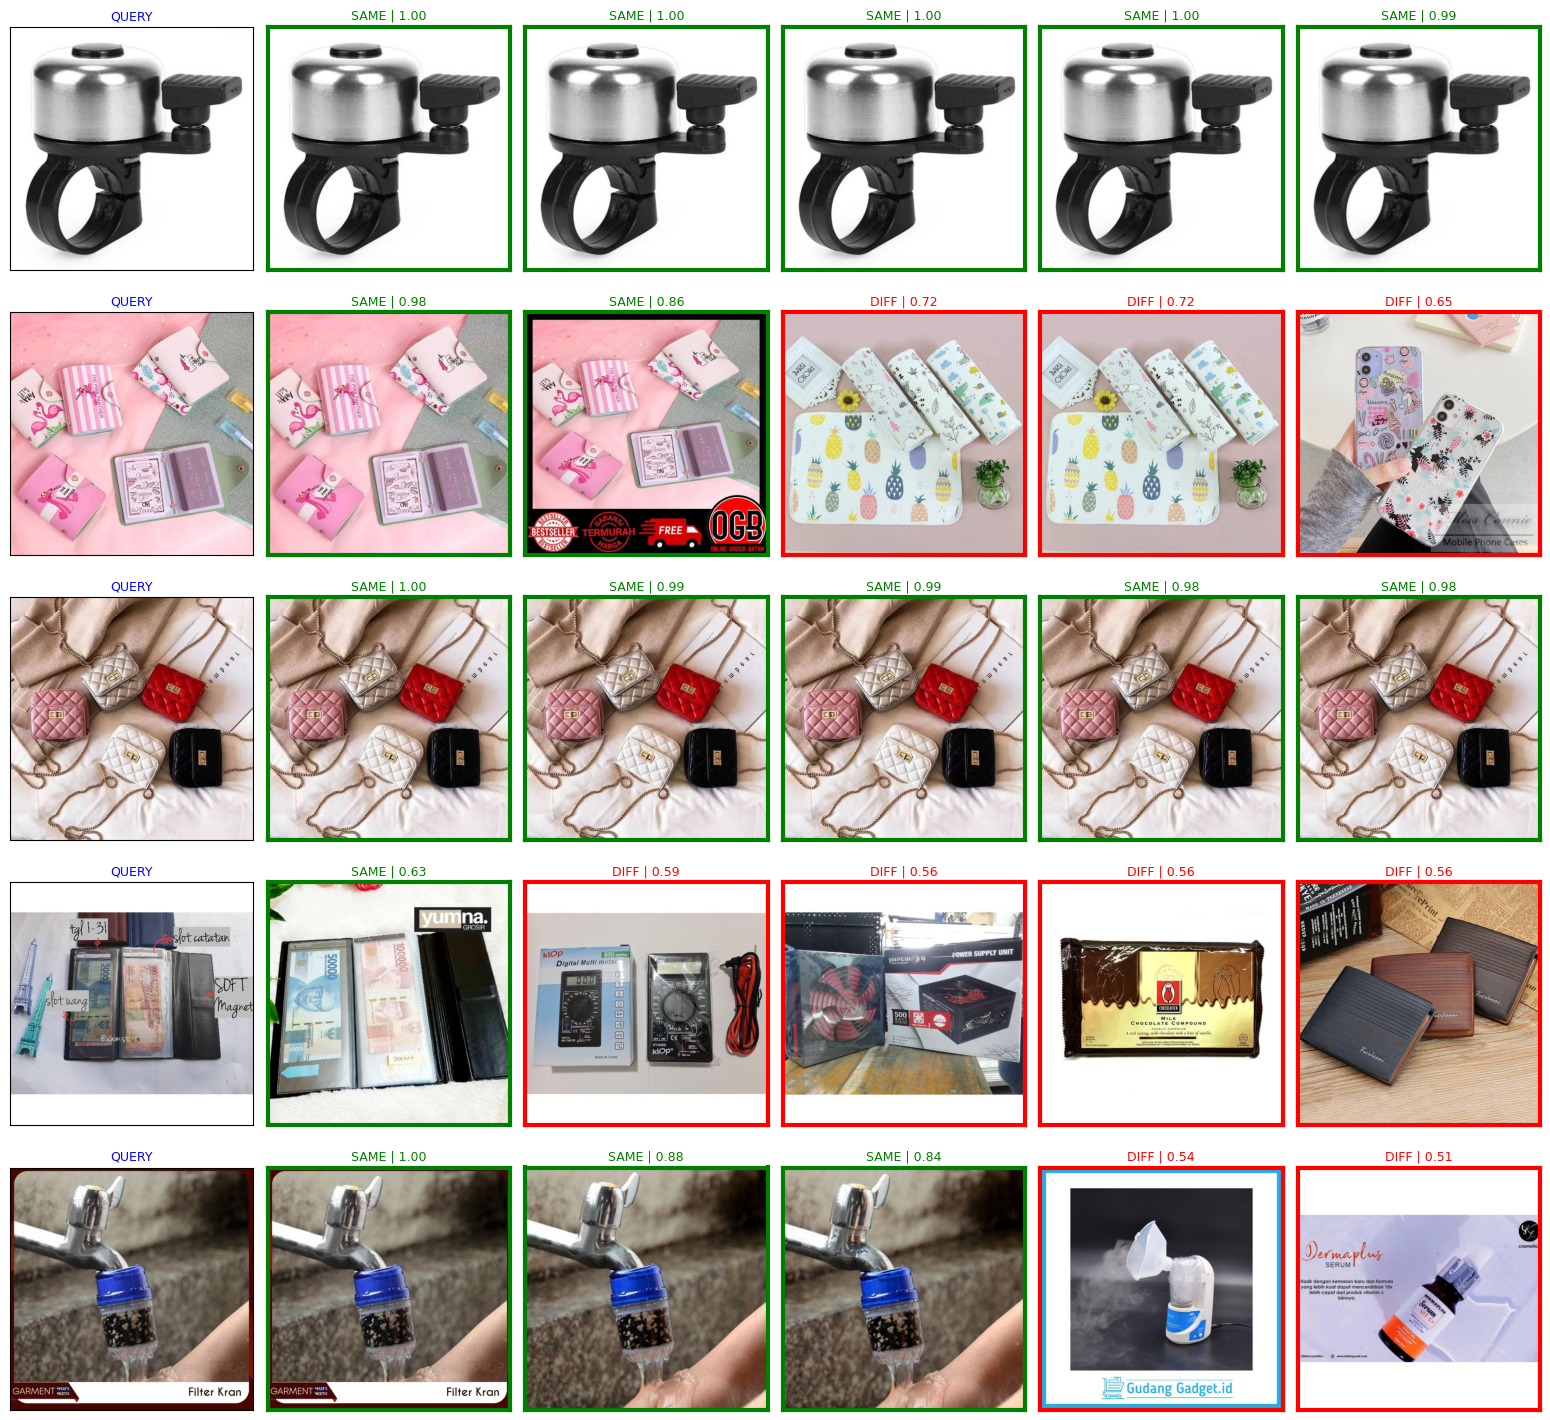

In [12]:
best_E = E_clip if "CLIP" in res.set_index("Experiment").loc[final, "Model"] else E_rn
Et, lt, ft = best_E[te_idx], df["label_group"].values[te_idx], df["image"].values[te_idx]

def show_nn(queries, K=5):
    fig, axes = plt.subplots(len(queries), K + 1, figsize=(2.6 * (K + 1), 2.9 * len(queries)), squeeze=False)
    for r, q in enumerate(queries):
        s = Et @ Et[q]; s[q] = -np.inf
        top = np.argsort(-s)[:K]
        axes[r, 0].imshow(load_img(ft[q])); axes[r, 0].set_title("QUERY", fontsize=9, color="blue")
        for c, j in enumerate(top, start=1):
            ok = lt[j] == lt[q]
            axes[r, c].imshow(load_img(ft[j]))
            axes[r, c].set_title(f"{'SAME' if ok else 'DIFF'} | {s[j]:.2f}", fontsize=9, color="green" if ok else "red")
            for sp in axes[r, c].spines.values():
                sp.set_edgecolor("green" if ok else "red"); sp.set_linewidth(3)
        for a in axes[r]:
            a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.savefig(f"{RES_DIR}/nn_examples.png", dpi=130); plt.show()

cnt = pd.Series(lt).value_counts()
cands = np.where(pd.Series(lt).map(cnt).values >= 3)[0]
show_nn(rng.choice(cands, 5, replace=False))

TP=2494  FP=495  FN=290  TN=2289


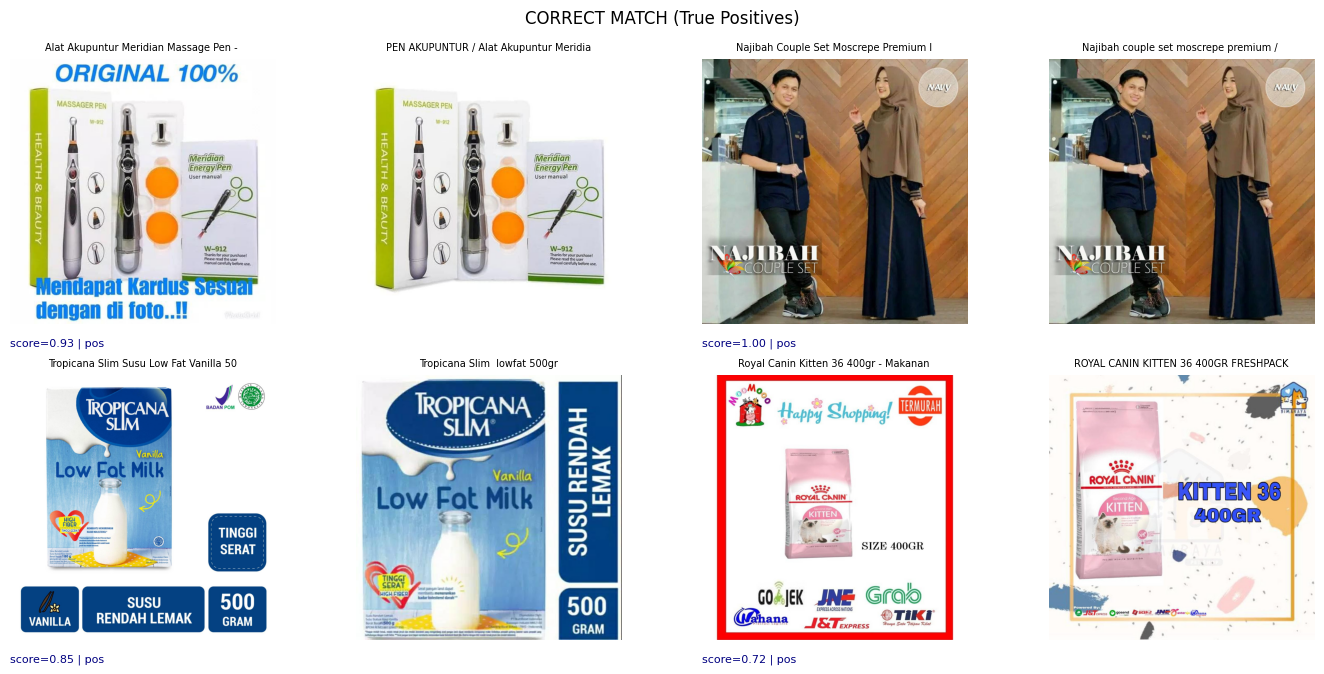

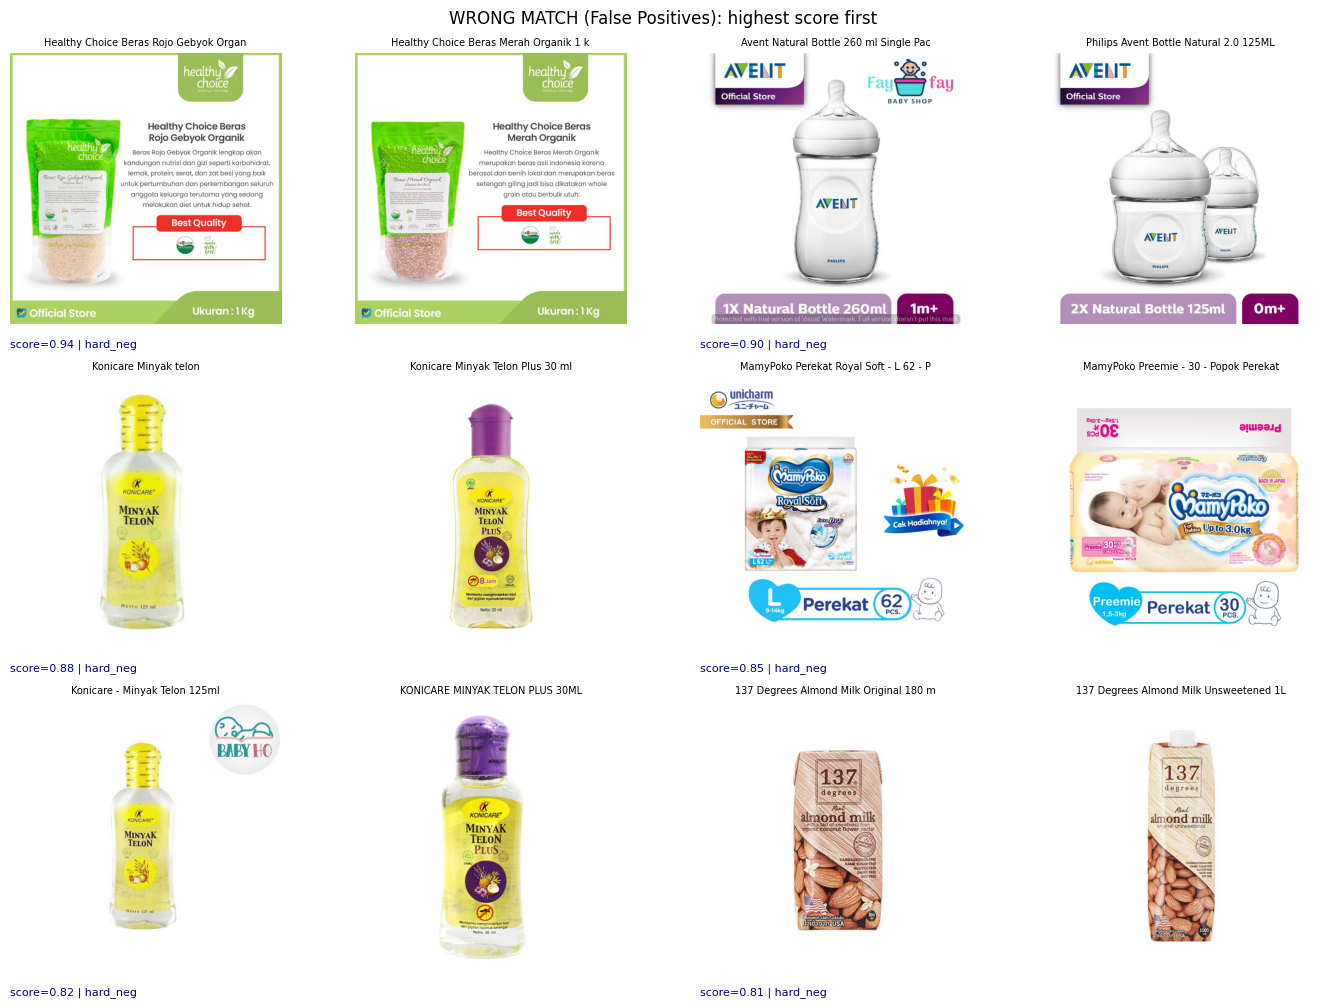

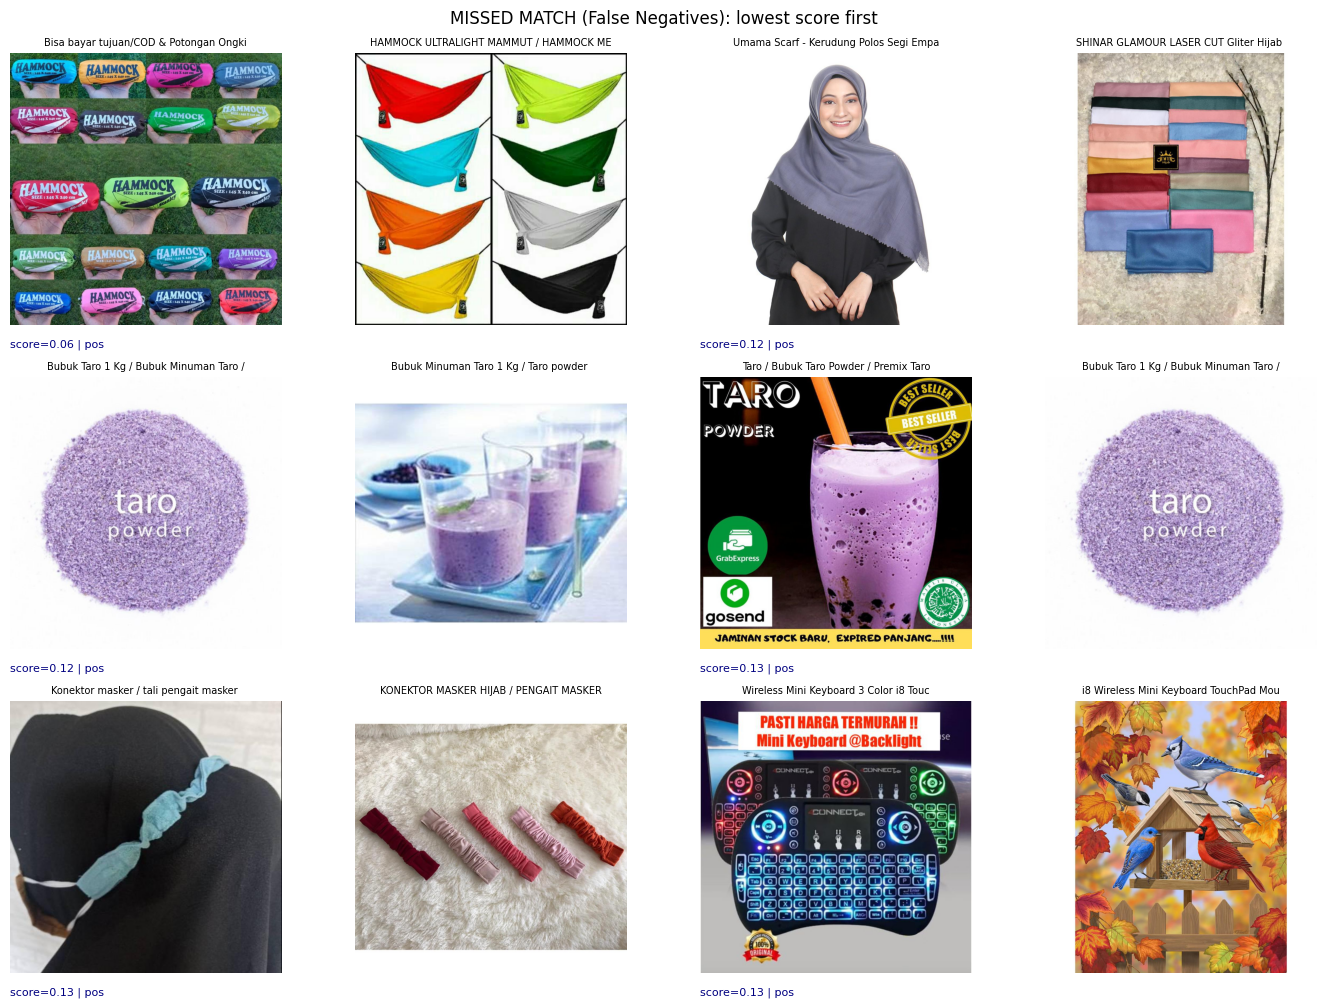

In [13]:
P_test["score"] = st_f
P_test["pred"] = (st_f >= thr_f).astype(int)
TP = P_test[(P_test.pred == 1) & (P_test.y == 1)]
FP = P_test[(P_test.pred == 1) & (P_test.y == 0)]
FN = P_test[(P_test.pred == 0) & (P_test.y == 1)]
TN = P_test[(P_test.pred == 0) & (P_test.y == 0)]
print(f"TP={len(TP)}  FP={len(FP)}  FN={len(FN)}  TN={len(TN)}")

def show_pairs(P, header, n=6, fname=None):
    P = P.head(n)
    fig, axes = plt.subplots(int(np.ceil(len(P) / 2)), 4, figsize=(14, 3.4 * int(np.ceil(len(P) / 2))), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for k, (_, r) in enumerate(P.iterrows()):
        row, col = divmod(k, 2)
        for side, c in [("a", 2 * col), ("b", 2 * col + 1)]:
            axes[row, c].imshow(load_img(r[f"img_{side}"]))
            axes[row, c].set_title(r[f"title_{side}"][:38], fontsize=7)
        axes[row, 2 * col].text(0, -0.08, f"score={r.score:.2f} | {r.kind}", transform=axes[row, 2 * col].transAxes, fontsize=8, color="navy")
    fig.suptitle(header, fontsize=12); plt.tight_layout()
    if fname: plt.savefig(f"{RES_DIR}/{fname}", dpi=130)
    plt.show()

show_pairs(TP.sample(4, random_state=1), "CORRECT MATCH (True Positives)", 4, "err_tp.png")
show_pairs(FP.sort_values("score", ascending=False), "WRONG MATCH (False Positives): highest score first", 6, "err_fp.png")
show_pairs(FN.sort_values("score"), "MISSED MATCH (False Negatives): lowest score first", 6, "err_fn.png")

In [14]:
used = np.unique(np.concatenate([P_test.a.values, P_test.b.values]))
isz = {i: Image.open(f"{IMG_DIR}/{df.image.values[i]}").size for i in used}

def stats(P):
    mins = np.array([min(min(isz[a]), min(isz[b])) for a, b in zip(P.a, P.b)])
    ar = np.array([abs(np.log((isz[a][0] / isz[a][1]) / (isz[b][0] / isz[b][1]))) for a, b in zip(P.a, P.b)])
    return mins, ar

rows = []
for name, Pp in [("TP", TP), ("FN", FN), ("FP", FP), ("TN", TN)]:
    mins, ar = stats(Pp)
    rows.append(dict(group=name, n=len(Pp), pct_low_res_lt300=round((mins < 300).mean() * 100, 1),
                     pct_aspect_ratio_mismatch=round((ar > 0.2).mean() * 100, 1),
                     pct_hard_neg=round((Pp.kind == "hard_neg").mean() * 100, 1)))
pd.DataFrame(rows)

,group,n,pct_low_res_lt300,pct_aspect_ratio_mismatch,pct_hard_neg
0,TP,2494,0.9,0.2,0.0
1,FN,290,0.7,0.3,0.0
2,FP,495,0.8,0.2,86.7
3,TN,2289,1.0,0.2,42.1


In [15]:
N = len(df)
rows = []
for name, E, key in [("ResNet50", E_rn_raw, "resnet50"), ("CLIP ViT-B/32", E_clip_raw, "clip_vitb32")]:
    t = TIMES.get(f"{key}_{N}")
    rows.append(dict(Model=name, Dim=E.shape[1], extract_time_s=t,
                     ms_per_image=round(1000 * t / N, 1) if t else None,
                     emb_memory_MB=round(E.nbytes / 1e6, 1),
                     emb_memory_full_34k_MB=round(34250 * E.shape[1] * 4 / 1e6, 1)))
display(pd.DataFrame(rows))

full_n = 34250
print(f"\nPairwise comparisons for full train ({full_n} images): {full_n*(full_n-1)//2:,}")
print(f"Full N x N float32 similarity matrix: {full_n**2 * 4 / 1e9:.1f} GB")
print(f"Test subset ({len(te_idx)} images) N x N matrix: {len(te_idx)**2 * 4 / 1e6:.0f} MB")

t0 = time.time(); _ = E_clip[te_idx] @ E_clip[te_idx].T
print(f"Brute-force similarity of test subset (matrix multiply): {time.time()-t0:.2f}s")

,Model,Dim,extract_time_s,ms_per_image,emb_memory_MB,emb_memory_full_34k_MB
0,ResNet50,2048,1170.4,117.0,81.9,280.6
1,CLIP ViT-B/32,512,757.0,75.7,20.5,70.1



Pairwise comparisons for full train (34250 images): 586,514,125
Full N x N float32 similarity matrix: 4.7 GB
Test subset (5121 images) N x N matrix: 105 MB
Brute-force similarity of test subset (matrix multiply): 0.13s


In [16]:
res.to_csv(f"{RES_DIR}/experiment_table.csv", index=False)
cfg = dict(seed=SEED, n_images=int(N), val_listings=len(va_idx), test_listings=len(te_idx),
           pairs=dict(val=len(P_val), test=len(P_test)), final_model=final, final_threshold=float(thr_f),
           models=["resnet50_imagenet_2048d", "clip-ViT-B-32_512d"], negatives="50% random + 50% hard (title TF-IDF mined)")
json.dump(cfg, open(f"{RES_DIR}/config.json", "w"), indent=2)
display(res)

,Experiment,Model,Dim,Similarity,Threshold,Val_F1,Test_P,Test_R,Test_F1,AUC,AP,AP_randneg,AP_hardneg
0,Baseline,ResNet50 (ImageNet),2048,Cosine,0.4543,0.8606,0.8344,0.8958,0.8640,0.9382,0.9438,0.9890,0.9507
1,Exp1,CLIP ViT-B/32,512,Cosine,0.6368,0.8486,0.8422,0.8495,0.8459,0.9255,0.9320,0.9864,0.9403
